CVAE Face Generation Project — TODO

1. Try to make a better Model (optional)
2. Try to do more attributes
3. Having a latenet space, see if changing one attribute changes other, or creates a completly new face
4. Check where the model fails
5. do a result analasys



Check where the model fails

In [2]:
import torch
from src.model import CVAE

SELECTED_ATTRIBUTES = [
        "Bald",
        "Black_Hair",
        "Blond_Hair",
        "Eyeglasses",
        "Male"
    ]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CVAE(latent_dim=128, n_classes=len(SELECTED_ATTRIBUTES), image_size=64)
model.load_state_dict(torch.load("cvae_good.pth"))
model.to(device)

CVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU()
    (5): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (fc_mu): Linear(in_features=4101, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=4101, out_features=128, bias=True)
  (decoder_input): Linear(in_features=133, out_features=4096, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): Ba

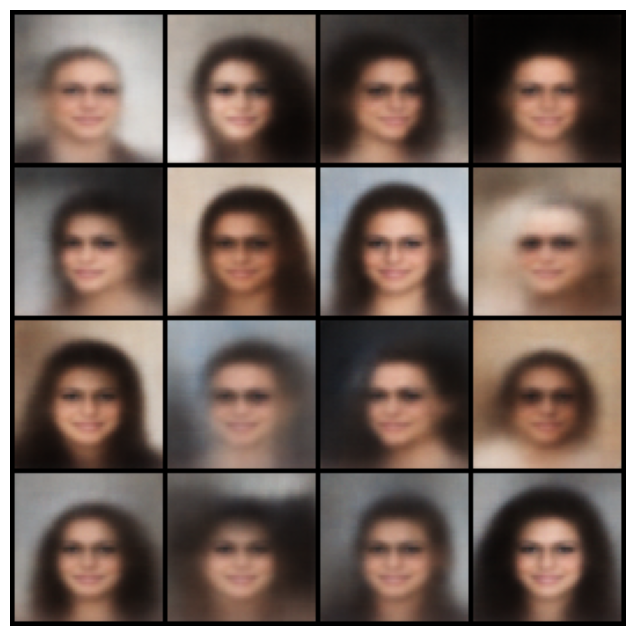

In [3]:
from src.utils import show_generated_faces

selected_attrs = {
    "Bald": 0,
    "Black_Hair": 1,
    "Blond_Hair": 0,
    "Eyeglasses": 1,
    "Male": 0
    }


show_generated_faces(
    model=model,
    selected_attrs=selected_attrs,
    attribute_names=SELECTED_ATTRIBUTES,
    latent_dim=128,
    n_samples=16,
    device=device
)   